In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, f1_score, classification_report


Exception ignored in PyObject_HasAttr(); consider using PyObject_HasAttrWithError(), PyObject_GetOptionalAttr() or PyObject_GetAttr():
Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 491, in _call_with_frames_removed
AttributeError: partially initialized module 'pandas' from 'c:\Users\New\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\__init__.py' has no attribute '_pandas_datetime_CAPI' (most likely due to a circular import)
Exception ignored in PyObject_HasAttr(); consider using PyObject_HasAttrWithError(), PyObject_GetOptionalAttr() or PyObject_GetAttr():
Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 491, in _call_with_frames_removed
AttributeError: partially initialized module 'pandas' from 'c:\Users\New\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\__init__.py' has no attribute '_pandas_parser_CAPI' (most likely due to a circular import)


In [3]:

# 1. Create synthetic dataset
X, y = make_classification(n_samples=1000, n_features=10, n_classes=2, random_state=42)

# 2. Fit logistic regression
model = LogisticRegression(solver='lbfgs')
model.fit(X, y)

# 3. Predict probabilities
y_prob = model.predict_proba(X)[:,1]   # probability of positive class
y_pred = model.predict(X)

#

In [6]:
# 4. Compute ROC curve
fpr, tpr, thresholds = roc_curve(y, y_prob)
auc = roc_auc_score(y, y_prob)

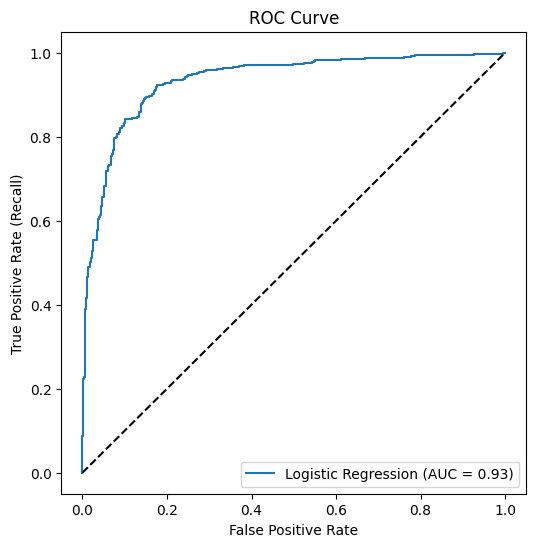

In [11]:
# 5. Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.2f})')
plt.plot([0,1],[0,1],'k--')  # diagonal line for random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.show()



In [12]:

# 6. F1 Score at default threshold (0.5)
print("F1 Score:", f1_score(y, y_pred))
print(classification_report(y, y_pred))

F1 Score: 0.8571428571428571
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       501
           1       0.87      0.85      0.86       499

    accuracy                           0.86      1000
   macro avg       0.86      0.86      0.86      1000
weighted avg       0.86      0.86      0.86      1000

